# DNA Sequence Analysis Toolkit

## Bioinformatics Portfolio Project

This project uses Python to explore foundational bioinformatics concepts through DNA sequence analysis.

The analysis will include:

- DNA sequence validation
- Nucleotide composition
- GC and AT content
- Complement and reverse-complement generation
- DNA transcription
- Protein translation
- Motif searching
- Open reading frame analysis
- Sequence visualization
- Analysis of real biological sequence data

## 1. Biological Background

DNA is composed of four nucleotide bases:

- **A** — Adenine
- **T** — Thymine
- **G** — Guanine
- **C** — Cytosine

The order of these bases stores genetic information.

In bioinformatics, DNA can be represented as a string of characters and analyzed computationally to identify sequence composition, patterns, coding regions, and other biological features.

In [1]:
dna_sequence = "ATGCGTACGTTAGCTAGCGGATCCGATCGATCGGCTAGCTAGCGATCGATGCGTACGATCGATCGTAGCTAGCTAGCGATCGATCGTACGATCGATCGTAGCTAGCTAA"

print(dna_sequence)

ATGCGTACGTTAGCTAGCGGATCCGATCGATCGGCTAGCTAGCGATCGATGCGTACGATCGATCGTAGCTAGCTAGCGATCGATCGTACGATCGATCGTAGCTAGCTAA


In [2]:
type(dna_sequence)

str

### Sequence Length

The sequence length represents the total number of nucleotide positions in the DNA sequence.

In [3]:
sequence_length = len(dna_sequence)

print(f"Sequence length: {sequence_length} nucleotides")

Sequence length: 109 nucleotides


### Nucleotide Composition

Nucleotide composition describes how many adenine, thymine, guanine, and cytosine bases occur within a DNA sequence.

In [4]:
a_count = dna_sequence.count("A")
t_count = dna_sequence.count("T")
g_count = dna_sequence.count("G")
c_count = dna_sequence.count("C")

print(f"Adenine (A): {a_count}")
print(f"Thymine (T): {t_count}")
print(f"Guanine (G): {g_count}")
print(f"Cytosine (C): {c_count}")

Adenine (A): 26
Thymine (T): 26
Guanine (G): 31
Cytosine (C): 26


In [5]:
#Quality Control Check
total_bases = a_count + t_count + g_count + c_count

print(f"Counted bases: {total_bases}")
print(f"Sequence length: {sequence_length}")

Counted bases: 109
Sequence length: 109


### DNA Sequence Validation

Before analyzing a biological sequence, the sequence should be checked for unexpected characters.

A standard DNA sequence should contain only:

**A, T, G, and C**

In [6]:
valid_bases = {"A", "T", "G", "C"}

is_valid = True

for base in dna_sequence:
    if base not in valid_bases:
        is_valid = False
        print(f"Invalid nucleotide detected: {base}")
        break

In [7]:
if is_valid:
    print("DNA sequence validation passed.")
else:
    print("DNA sequence validation failed.")

DNA sequence validation passed.


In [8]:
#testing invalid sequence
test_sequence = "ATGCGTXACG"

for base in test_sequence:
    if base not in valid_bases:
        print(f"Invalid nucleotide detected: {base}")

Invalid nucleotide detected: X


### GC Content

GC content is the percentage of nucleotides in a DNA sequence that are either guanine (G) or cytosine (C).

GC content is a commonly used characteristic of genomic sequences and can vary between organisms and genomic regions.

In [9]:
gc_content = ((g_count + c_count) / sequence_length) * 100

print(f"GC content: {gc_content:.2f}%")

GC content: 52.29%


In [10]:
at_content = ((a_count + t_count) / sequence_length) * 100

print(f"AT content: {at_content:.2f}%")

AT content: 47.71%


In [11]:
#sanity check
gc_content + at_content

100.0

## 2. DNA Complement and Transcription

DNA is double-stranded, and each nucleotide pairs with a complementary base:

- A pairs with T
- T pairs with A
- G pairs with C
- C pairs with G

The complementary strand can be generated computationally by replacing each nucleotide with its paired base.

For many bioinformatics tasks, the **reverse complement** is especially important because DNA strands run in opposite directions.

DNA can also be transcribed into RNA, where thymine (T) is replaced by uracil (U).

In [12]:
complement_map = {
    "A": "T",
    "T": "A",
    "G": "C",
    "C": "G"
}

complement_sequence = ""

for base in dna_sequence:
    complement_sequence += complement_map[base]

print("Original DNA:")
print(dna_sequence)

print("\nComplement:")
print(complement_sequence)

Original DNA:
ATGCGTACGTTAGCTAGCGGATCCGATCGATCGGCTAGCTAGCGATCGATGCGTACGATCGATCGTAGCTAGCTAGCGATCGATCGTACGATCGATCGTAGCTAGCTAA

Complement:
TACGCATGCAATCGATCGCCTAGGCTAGCTAGCCGATCGATCGCTAGCTACGCATGCTAGCTAGCATCGATCGATCGCTAGCTAGCATGCTAGCTAGCATCGATCGATT


### Reverse Complement

Because DNA strands are antiparallel, the biologically useful representation of the opposite strand is often the **reverse complement**.

The reverse complement is created by:

1. Generating the complementary strand
2. Reversing its order

In [13]:
reverse_complement = complement_sequence[::-1]

print("Original DNA:")
print(dna_sequence)

print("\nReverse Complement:")
print(reverse_complement)

Original DNA:
ATGCGTACGTTAGCTAGCGGATCCGATCGATCGGCTAGCTAGCGATCGATGCGTACGATCGATCGTAGCTAGCTAGCGATCGATCGTACGATCGATCGTAGCTAGCTAA

Reverse Complement:
TTAGCTAGCTACGATCGATCGTACGATCGATCGCTAGCTAGCTACGATCGATCGTACGCATCGATCGCTAGCTAGCCGATCGATCGGATCCGCTAGCTAACGTACGCAT


In [14]:
#quick bio check
test_dna = "ATGC"

test_complement = ""

for base in test_dna:
    test_complement += complement_map[base]

test_reverse_complement = test_complement[::-1]

print(f"Original: {test_dna}")
print(f"Complement: {test_complement}")
print(f"Reverse complement: {test_reverse_complement}")

Original: ATGC
Complement: TACG
Reverse complement: GCAT


### DNA Transcription

During transcription, DNA is used as the basis for RNA production.

RNA differs from DNA in that RNA uses **uracil (U)** instead of **thymine (T)**.

For a coding DNA sequence, transcription can be represented computationally by replacing each T with U.

In [15]:
rna_sequence = dna_sequence.replace("T", "U")

print("DNA:")
print(dna_sequence)

print("\nRNA:")
print(rna_sequence)

DNA:
ATGCGTACGTTAGCTAGCGGATCCGATCGATCGGCTAGCTAGCGATCGATGCGTACGATCGATCGTAGCTAGCTAGCGATCGATCGTACGATCGATCGTAGCTAGCTAA

RNA:
AUGCGUACGUUAGCUAGCGGAUCCGAUCGAUCGGCUAGCUAGCGAUCGAUGCGUACGAUCGAUCGUAGCUAGCUAGCGAUCGAUCGUACGAUCGAUCGUAGCUAGCUAA


In [16]:
#RNA validation check
valid_rna_bases = {"A", "U", "G", "C"}

rna_is_valid = True

for base in rna_sequence:
    if base not in valid_rna_bases:
        rna_is_valid = False
        print(f"Invalid RNA nucleotide detected: {base}")
        break

if rna_is_valid:
    print("RNA sequence validation passed.")
else:
    print("RNA sequence validation failed.")

RNA sequence validation passed.


In [17]:
#Comparing DNA and RNA length
print(f"DNA length: {len(dna_sequence)}")
print(f"RNA length: {len(rna_sequence)}")

DNA length: 109
RNA length: 109


### Verification with Biopython

The previous sequence operations were implemented manually to demonstrate the underlying logic.

Biopython provides specialized tools for biological sequence manipulation. The manually generated results can be compared against Biopython to confirm that the calculations are correct.

In [18]:
from Bio.Seq import Seq

bio_sequence = Seq(dna_sequence)

bio_complement = bio_sequence.complement()
bio_reverse_complement = bio_sequence.reverse_complement()
bio_rna = bio_sequence.transcribe()

print("Biopython complement:")
print(bio_complement)

print("\nBiopython reverse complement:")
print(bio_reverse_complement)

print("\nBiopython RNA:")
print(bio_rna)

Biopython complement:
TACGCATGCAATCGATCGCCTAGGCTAGCTAGCCGATCGATCGCTAGCTACGCATGCTAGCTAGCATCGATCGATCGCTAGCTAGCATGCTAGCTAGCATCGATCGATT

Biopython reverse complement:
TTAGCTAGCTACGATCGATCGTACGATCGATCGCTAGCTAGCTACGATCGATCGTACGCATCGATCGCTAGCTAGCCGATCGATCGGATCCGCTAGCTAACGTACGCAT

Biopython RNA:
AUGCGUACGUUAGCUAGCGGAUCCGAUCGAUCGGCUAGCUAGCGAUCGAUGCGUACGAUCGAUCGUAGCUAGCUAGCGAUCGAUCGUACGAUCGAUCGUAGCUAGCUAA


In [19]:
import sys
print(sys.executable)

c:\Users\amber\OneDrive\Documents\GitHub\DNA_Sequence_Analysis\DNA_Sequence_Analysis\.venv\Scripts\python.exe


In [20]:
%pip install biopython

Note: you may need to restart the kernel to use updated packages.


# 3. DNA Translation

DNA stores genetic information.

Proteins are built from amino acids.

The genetic code is read three nucleotides at a time.

Each group of three nucleotides is called a **codon**.

For example:

ATG → Methionine (Start)

TTT → Phenylalanine

TAA → Stop

The purpose of this section is to identify codons and translate DNA into protein.

In [21]:
# ------------- CODONS --------------
codons = []

for i in range(0, len(dna_sequence), 3):
    codon = dna_sequence[i:i+3]

    if len(codon) == 3:
        codons.append(codon)

print("First 10 codons:")

for codon in codons[:10]:
    print(codon)

First 10 codons:
ATG
CGT
ACG
TTA
GCT
AGC
GGA
TCC
GAT
CGA


In [22]:
print(f"Total codons: {len(codons)}")

Total codons: 36


In [23]:
#Finding the start codon
start_positions = []

for i, codon in enumerate(codons):

    if codon == "ATG":
        start_positions.append(i)

print(start_positions)

[0, 16]


In [24]:
#Finding the stop codons
stop_codons = {"TAA", "TAG", "TGA"}

stop_positions = []

for i, codon in enumerate(codons):

    if codon in stop_codons:
        stop_positions.append(i)

print(stop_positions)

[13, 23, 34]


In [25]:
#Using Biopython to translate
protein = bio_sequence.translate()

print(protein)

MRTLASGSDRSAS*RSMRTIDRS*LAIDRTIDRS*L


c:\Users\amber\OneDrive\Documents\GitHub\DNA_Sequence_Analysis\DNA_Sequence_Analysis\.venv\Lib\site-packages\Bio\Seq.py:2874: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(


Each letter is an amino acid:

M = Methionine

A = Alanine

L = Leucine

V = Valine

G = Glycine

In [26]:
#Compare lengths
print("DNA length:", len(dna_sequence))

print("Protein length:", len(protein))

DNA length: 109
Protein length: 36


Notice, the protein length is roughly one-thirf of the DNA length because 3 DNA bases --> 1 codon --> 1 amino acid

In [27]:
import pandas as pd

codon_df = pd.DataFrame({
    "Codon Number": range(1, len(codons)+1),
    "Codon": codons
})

codon_df.head(15)

,Codon Number,Codon
0,1,ATG
1,2,CGT
2,3,ACG
3,4,TTA
4,5,GCT
5,6,AGC
6,7,GGA
7,8,TCC
8,9,GAT
9,10,CGA


# 4. Working With Real Biological Sequence Data

The previous analyses used a short example DNA sequence to demonstrate core bioinformatics concepts.

This section uses a real nucleotide sequence obtained from the National Center for Biotechnology Information (NCBI).

The sequence analyzed here is the *Escherichia coli* lactose operon, which contains genes involved in lactose metabolism.

NCBI accession: **J01636.1**

In [28]:
from Bio import SeqIO

In [35]:
fasta_file = "../data/raw/sequence.fasta"

record = SeqIO.read(fasta_file, "fasta")

## Inspecting the FASTA Record

Before performing analysis, it is important to inspect the imported sequence.

The FASTA record contains:

- Sequence ID
- Description
- DNA sequence
- Sequence length

In [36]:
print("Sequence ID:")
print(record.id)

print("\nDescription:")
print(record.description)

print("\nSequence Length:")
print(f"{len(record.seq):,} bp")

Sequence ID:
J01636.1

Description:
J01636.1 E.coli lactose operon with lacI, lacZ, lacY and lacA genes

Sequence Length:
7,477 bp


In [37]:
#looking at the first 100 nucleotides
print("First 100 bases")

print(record.seq[:100])

First 100 bases
GACACCATCGAATGGCGCAAAACCTTTCGCGGTATGGCATGATAGCGCCCGGAAGAGAGTCAATTCAGGGTGGTGAATGTGAAACCAGTAACGTTATACG


In [38]:
#last 100 nucleotides
print("Last 100 bases")

print(record.seq[-100:])

Last 100 bases
CAGACTGATGGCGACACTGCGACGTTCGCTGACATGCTGATGAAGCCAGCTTCCGGCCAGCGCCAGCCCGCCCATGGTAACCACCGGCAGAGCGGTCGAC


In [39]:
#Converting to a normal python string 
real_dna = str(record.seq).upper()

In [40]:
print(type(record.seq))
print(type(real_dna))

<class 'Bio.Seq.Seq'>
<class 'str'>


In [41]:
#Validating the sequence
valid_bases = {"A", "T", "G", "C"}

unique_bases = set(real_dna)

print(unique_bases)

{'A', 'C', 'T', 'G'}


In [42]:
invalid = unique_bases - valid_bases

print(invalid)

set()


In [43]:
#Count nucleotides
nucleotide_counts = {}

for base in valid_bases:
    nucleotide_counts[base] = real_dna.count(base)

nucleotide_counts

{'A': 1739, 'C': 1991, 'T': 1743, 'G': 2004}

In [44]:
import pandas as pd

nucleotide_df = pd.DataFrame(
    nucleotide_counts.items(),
    columns=["Nucleotide", "Count"]
)

nucleotide_df

,Nucleotide,Count
0,A,1739
1,C,1991
2,T,1743
3,G,2004


In [45]:
sequence_length = len(real_dna)

nucleotide_df["Percentage"] = (
    nucleotide_df["Count"] / sequence_length
) * 100

nucleotide_df

,Nucleotide,Count,Percentage
0,A,1739,23.257991
1,C,1991,26.628327
2,T,1743,23.311489
3,G,2004,26.802193


In [46]:
#Calculate GC content
gc_count = nucleotide_counts["G"] + nucleotide_counts["C"]
at_count = nucleotide_counts["A"] + nucleotide_counts["T"]

gc_content = (gc_count / sequence_length) * 100
at_content = (at_count / sequence_length) * 100

print(f"GC Content: {gc_content:.2f}%")
print(f"AT Content: {at_content:.2f}%")
print(f"Total: {gc_content + at_content:.2f}%")

GC Content: 53.43%
AT Content: 46.57%
Total: 100.00%


**Why does GC content matter?**

- GC rich DNA behaves differently

- melts at higher tempretures

- is often harder to PCR amplify

- folds differently

- can indicate different funcitonal regions 

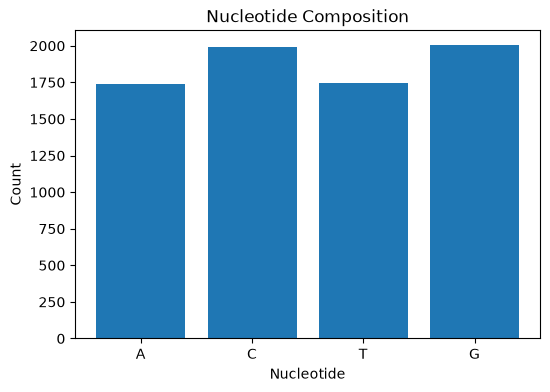

In [47]:
#Visualize
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    nucleotide_df["Nucleotide"],
    nucleotide_df["Count"]
)

plt.title("Nucleotide Composition")
plt.xlabel("Nucleotide")
plt.ylabel("Count")

plt.show()

## Sliding-Window GC Content

Overall GC content summarizes an entire sequence with one value.

However, nucleotide composition can vary across different regions of a sequence.

A sliding-window analysis calculates GC content across smaller sections of DNA, allowing local changes in sequence composition to be visualized.

In [ ]:
window_size = 100 #analyze 100 bases at a time

positions = []
gc_values = []

for start in range(0, len(real_dna) - window_size + 1, window_size):
    window = real_dna[start:start + window_size]

    g_count = window.count("G")
    c_count = window.count("C")

    window_gc = ((g_count + c_count) / len(window)) * 100

    positions.append(start)
    gc_values.append(window_gc)

In [54]:
print(positions[:10])
print(gc_values[:10])

[0, 100, 200, 300, 400, 500, 600, 700, 800, 900]
[50.0, 56.99999999999999, 59.0, 60.0, 56.99999999999999, 48.0, 56.99999999999999, 52.0, 62.0, 54.0]


In [55]:
gc_window_df = pd.DataFrame({
    "Position": positions,
    "GC_Content": gc_values
})

gc_window_df.head(10)

,Position,GC_Content
0,0,50.0
1,100,57.0
2,200,59.0
3,300,60.0
4,400,57.0
5,500,48.0
6,600,57.0
7,700,52.0
8,800,62.0
9,900,54.0


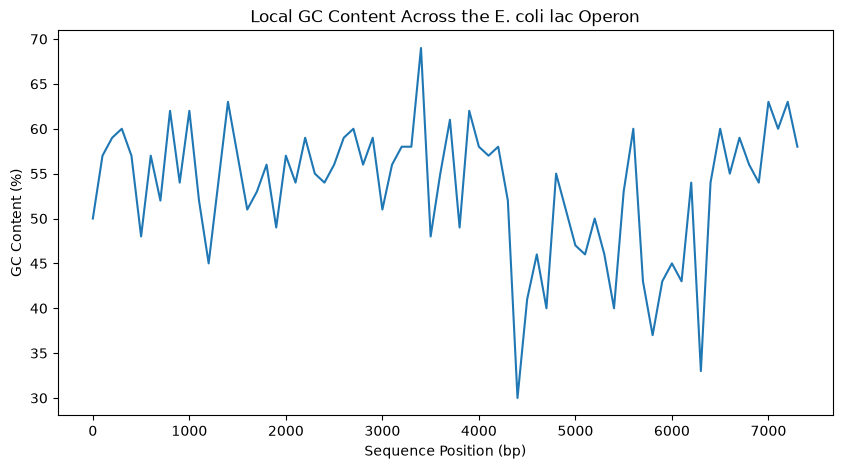

In [56]:
plt.figure(figsize=(10, 5))

plt.plot(
    gc_window_df["Position"],
    gc_window_df["GC_Content"]
)

plt.title("Local GC Content Across the E. coli lac Operon")
plt.xlabel("Sequence Position (bp)")
plt.ylabel("GC Content (%)")

plt.show()

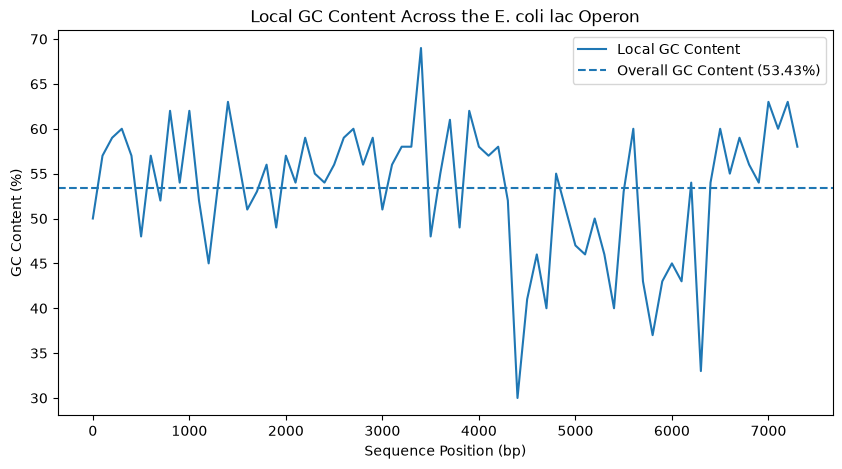

In [57]:
plt.figure(figsize=(10, 5))

plt.plot(
    gc_window_df["Position"],
    gc_window_df["GC_Content"],
    label="Local GC Content"
)

plt.axhline(
    y=gc_content,
    linestyle="--",
    label=f"Overall GC Content ({gc_content:.2f}%)"
)

plt.title("Local GC Content Across the E. coli lac Operon")
plt.xlabel("Sequence Position (bp)")
plt.ylabel("GC Content (%)")
plt.legend()

plt.show()